# Depth-Scaling Analysis

This notebook accompanies the depth-scaling experiment, which demonstrates that
the COGITAO generator supports **compositional depths well beyond 3** (tested up
to depth 8).

It provides:
1. **Generation metrics** — wall-clock time and throughput vs. depth
2. **Sample visualisation** — example input/output pairs at each depth
3. **Summary table** — all metrics in one place

## Prerequisites

Run the generation script first:
```bash
python supplementary_material_experiments/run_depth_scaling.py \
    --num-workers 16 --n-samples 1000 --output-dir ./data/depth_scaling
```

In [9]:
%load_ext autoreload
%autoreload 2

import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from arcworld.constants import COLORMAP, NORM

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# --- Configuration ---
DATA_DIR = Path("../data/depth_scaling")  # adjust if you used a different --output-dir
DEPTHS = list(range(1, 9))

## 1. Generation Metrics

In [11]:
# Load metrics
metrics_path = DATA_DIR / "generation_metrics.json"
with open(metrics_path) as f:
    metrics = json.load(f)

depths = []
wall_times = []
throughputs = []
n_combos_list = []
n_generated_list = []
n_requested_list = []

for d in DEPTHS:
    key = f"depth_{d}"
    if key not in metrics:
        continue
    m = metrics[key]
    depths.append(m["depth"])
    wall_times.append(m["wall_time_seconds"])
    throughputs.append(m["samples_per_second"])
    n_combos_list.append(m["n_combos"])
    n_generated_list.append(m["n_generated"])
    n_requested_list.append(m["n_requested"])

print(f"Loaded metrics for {len(depths)} depths")

Loaded metrics for 8 depths


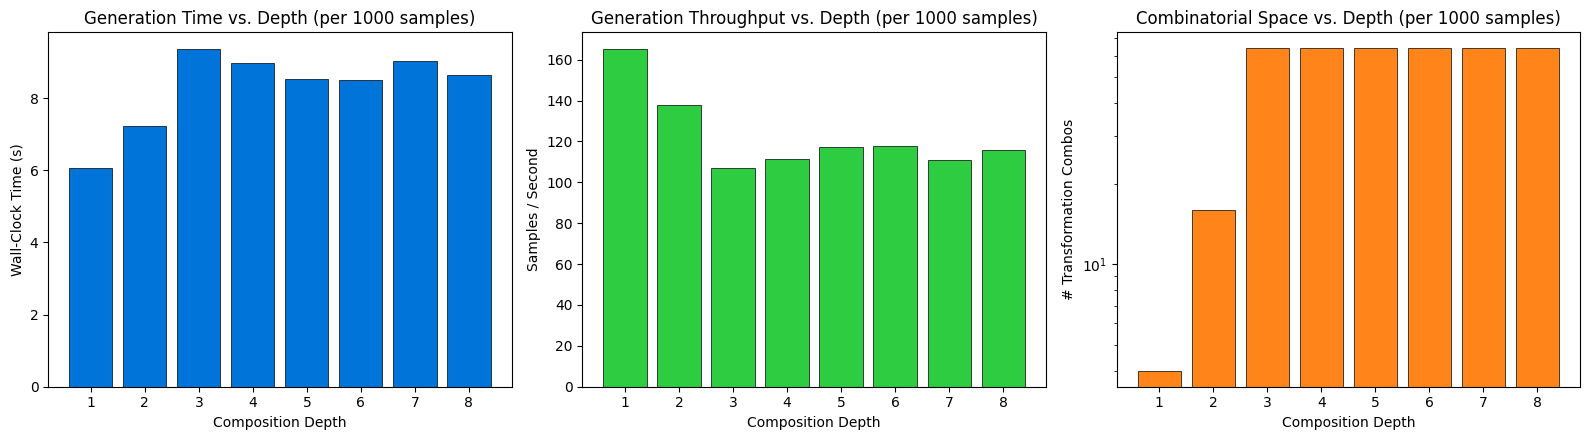

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- Wall-clock time ---
ax = axes[0]
ax.bar(depths, wall_times, color="#0074D9", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Composition Depth")
ax.set_ylabel("Wall-Clock Time (s)")
ax.set_title("Generation Time vs. Depth for 1000 samples")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- Throughput ---
ax = axes[1]
ax.bar(depths, throughputs, color="#2ECC40", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Composition Depth")
ax.set_ylabel("Samples / Second")
ax.set_title("Generation Throughput vs. Depth for 1000 samples")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- Number of combos ---
ax = axes[2]
ax.bar(depths, n_combos_list, color="#FF851B", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Composition Depth")
ax.set_ylabel("# Transformation Combos")
ax.set_title("Combinatorial Space vs. Depth for 1000 samples")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_yscale("log")

plt.tight_layout()
plt.savefig(DATA_DIR / "generation_metrics.pdf", bbox_inches="tight", dpi=150)
plt.savefig(DATA_DIR / "generation_metrics.png", bbox_inches="tight", dpi=150)
plt.show()

## 2. Sample Visualisation per Depth

For each depth, we display one random input-output pair from the generated dataset.

In [8]:
def load_sample(data_dir, depth, idx=0):
    """Load a single sample (input, output, transformation_suite) from an HDF5 file."""
    h5_path = data_dir / f"depth_{depth}" / "data.h5"
    with h5py.File(h5_path, "r") as f:
        grid_size = f["grid_sizes"][idx]
        h, w = int(grid_size[0]), int(grid_size[1])
        inp = f["inputs"][idx, :h, :w]
        out = f["outputs"][idx, :h, :w]
        ts = json.loads(f["transformation_suites"][idx])
    return inp, out, ts

/var/folders/vw/9_mx55bd2xv8_v7v_67539680000gn/T/ipykernel_34317/4252558657.py:48: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


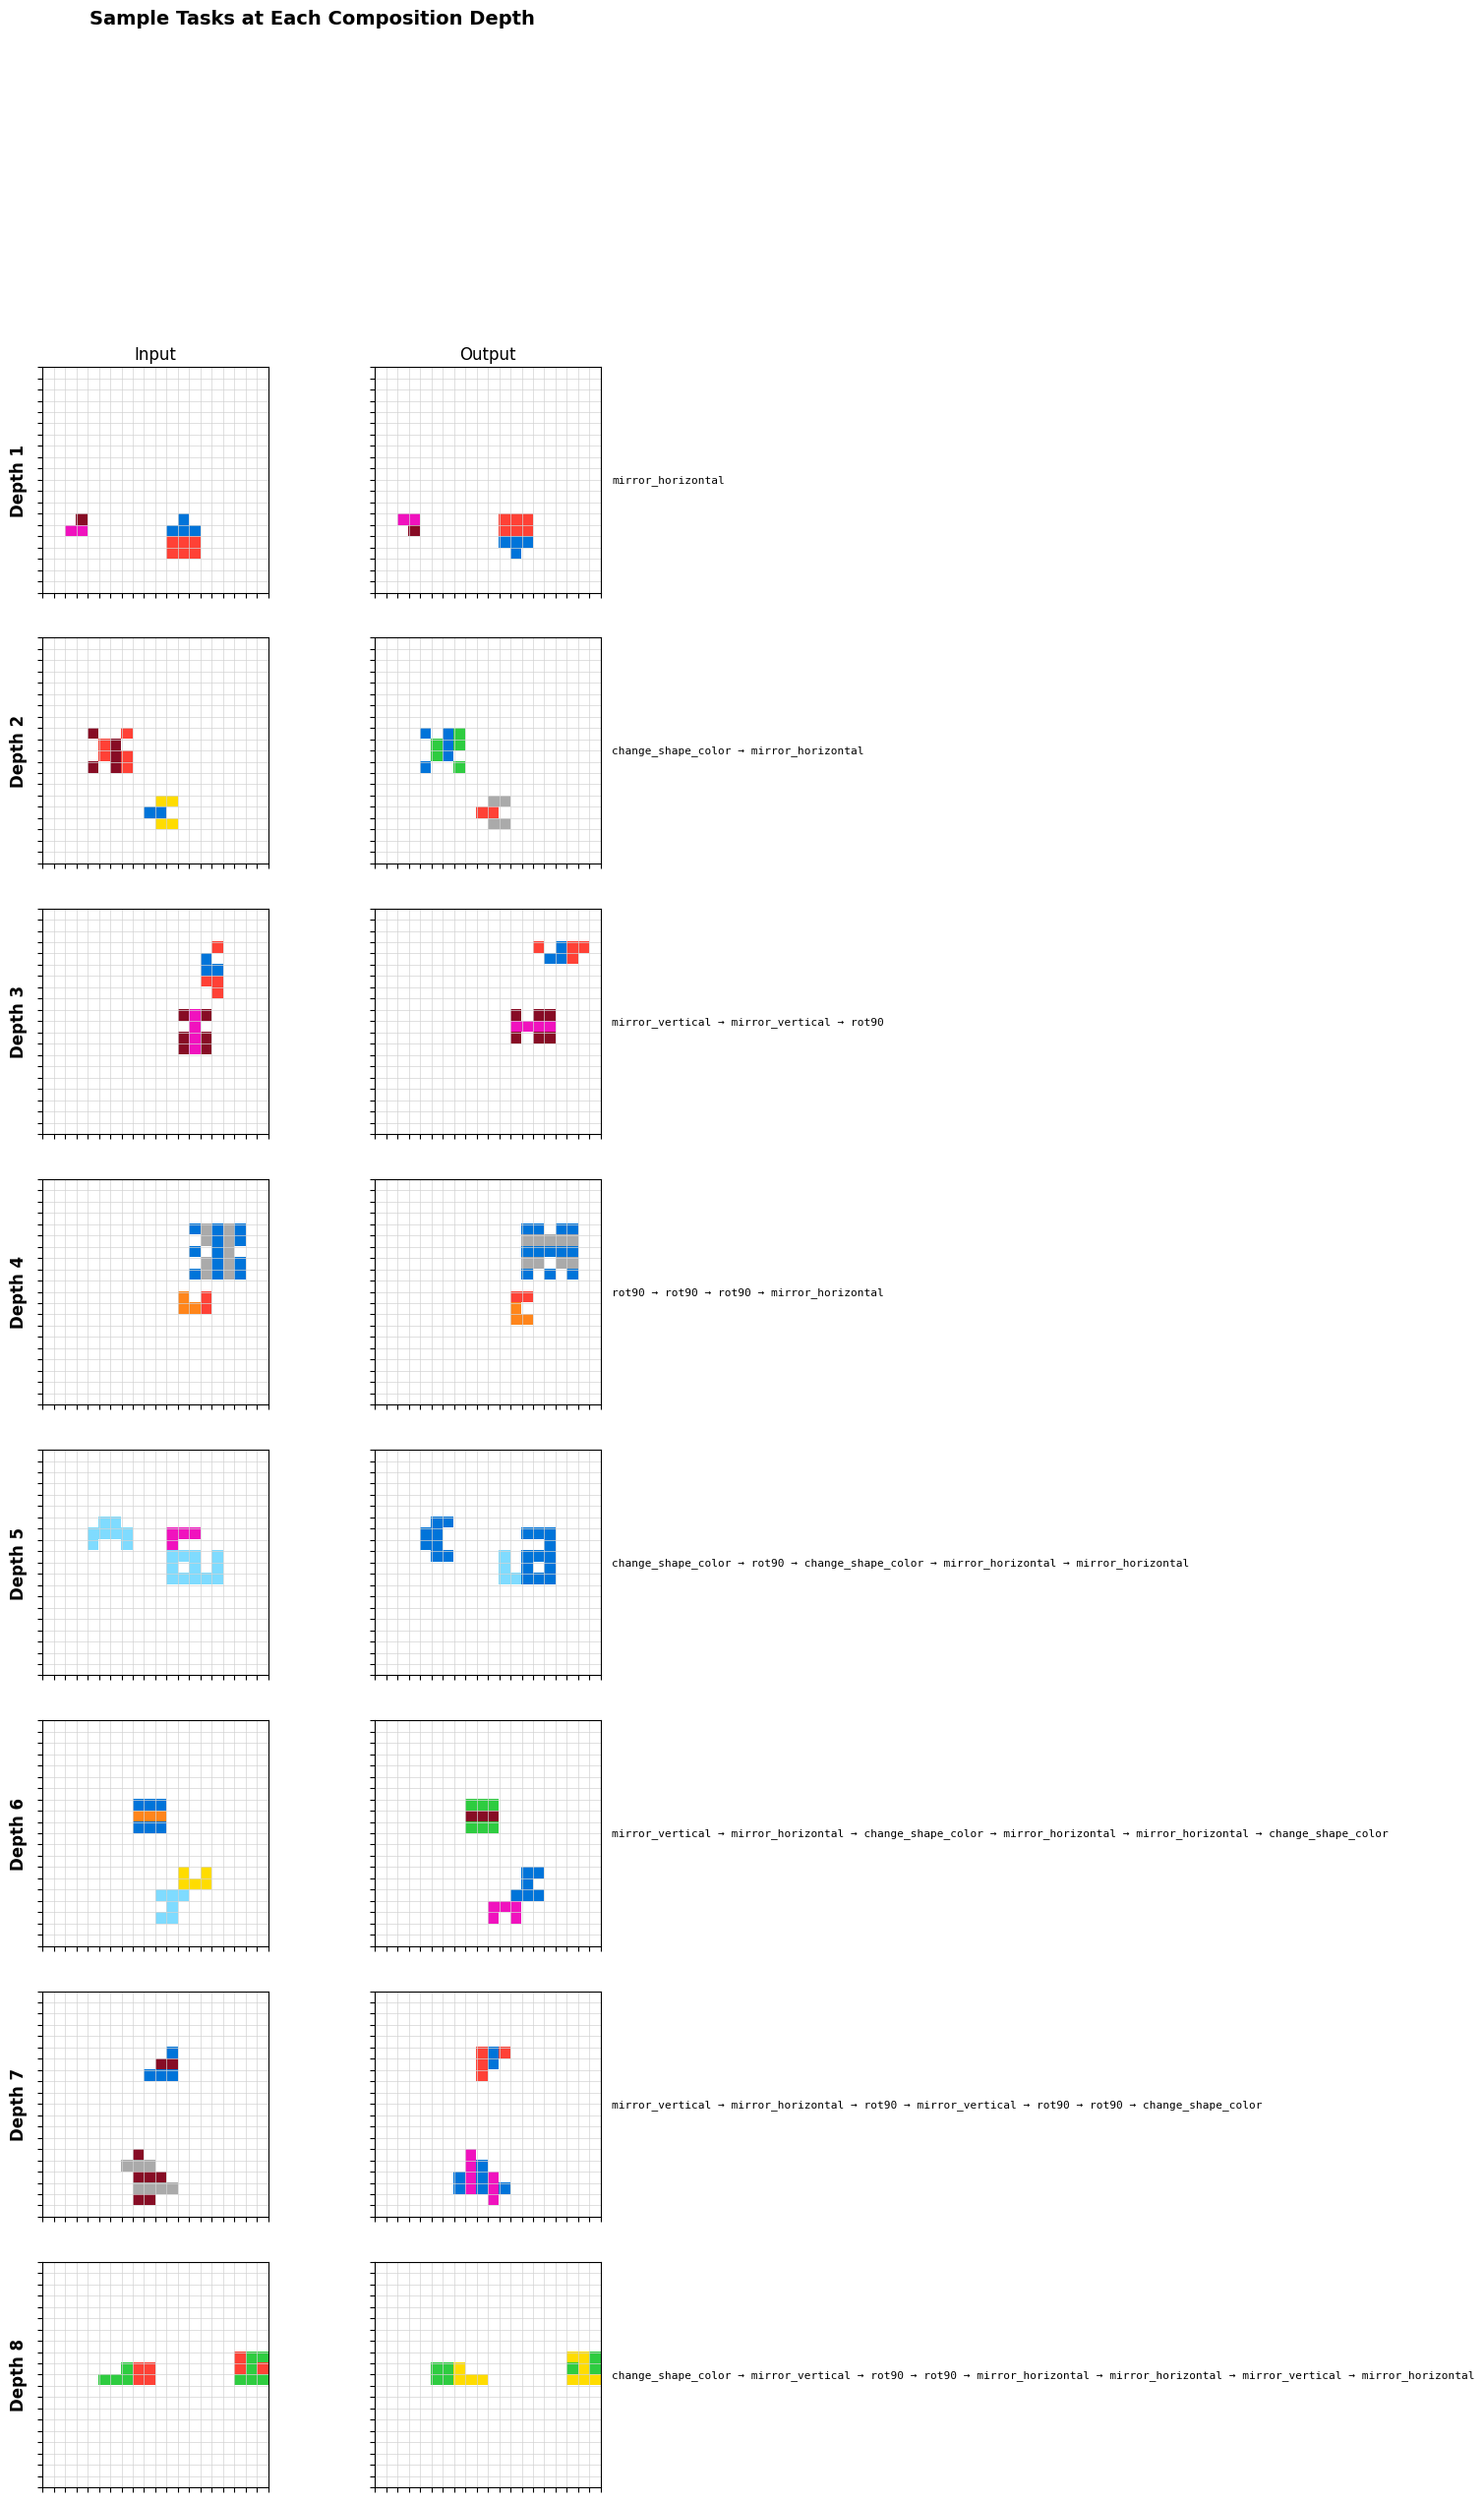

In [9]:
n_depths = len(depths)
fig, axes = plt.subplots(n_depths, 2, figsize=(8, 3.5 * n_depths))

for row, d in enumerate(depths):
    # Pick a random sample
    rng = np.random.default_rng(seed=d)
    h5_path = DATA_DIR / f"depth_{d}" / "data.h5"
    with h5py.File(h5_path, "r") as f:
        n_samples = f["inputs"].shape[0]
    sample_idx = int(rng.integers(0, n_samples))
    inp, out, ts = load_sample(DATA_DIR, d, sample_idx)

    # Plot input
    ax_in = axes[row, 0]
    ax_in.imshow(inp, cmap=COLORMAP, norm=NORM)
    ax_in.grid(True, which="both", color="lightgrey", linewidth=0.5)
    ax_in.set_yticks([x - 0.5 for x in range(1 + inp.shape[0])])
    ax_in.set_xticks([x - 0.5 for x in range(1 + inp.shape[1])])
    ax_in.set_xticklabels([])
    ax_in.set_yticklabels([])
    ax_in.set_ylabel(f"Depth {d}", fontsize=12, fontweight="bold")
    if row == 0:
        ax_in.set_title("Input", fontsize=12)

    # Plot output
    ax_out = axes[row, 1]
    ax_out.imshow(out, cmap=COLORMAP, norm=NORM)
    ax_out.grid(True, which="both", color="lightgrey", linewidth=0.5)
    ax_out.set_yticks([x - 0.5 for x in range(1 + out.shape[0])])
    ax_out.set_xticks([x - 0.5 for x in range(1 + out.shape[1])])
    ax_out.set_xticklabels([])
    ax_out.set_yticklabels([])
    if row == 0:
        ax_out.set_title("Output", fontsize=12)

    # Annotate with transformation suite
    chain_str = " \u2192 ".join(ts)
    ax_out.annotate(
        chain_str,
        xy=(1.05, 0.5),
        xycoords="axes fraction",
        fontsize=8,
        va="center",
        fontfamily="monospace",
    )

fig.suptitle("Sample Tasks at Each Composition Depth", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "sample_tasks_per_depth.pdf", bbox_inches="tight", dpi=150)
plt.savefig(DATA_DIR / "sample_tasks_per_depth.png", bbox_inches="tight", dpi=150)
plt.show()

## 3. Summary Table

In [10]:
try:
    import pandas as pd

    df = pd.DataFrame({
        "Depth": depths,
        "# Combos": n_combos_list,
        "Requested": n_requested_list,
        "Generated": n_generated_list,
        "Success Rate": [f"{g / r * 100:.1f}%" for g, r in zip(n_generated_list, n_requested_list)],
        "Wall Time (s)": wall_times,
        "Throughput (samples/s)": throughputs,
    })
    display(df.style.hide(axis="index"))
except ImportError:
    # Fallback without pandas
    header = f"{'Depth':>5} {'#Combos':>8} {'Req':>6} {'Gen':>6} {'Time(s)':>8} {'Samp/s':>8}"
    print(header)
    print("-" * len(header))
    for i, d in enumerate(depths):
        print(f"{d:>5} {n_combos_list[i]:>8} {n_requested_list[i]:>6} {n_generated_list[i]:>6} {wall_times[i]:>8.1f} {throughputs[i]:>8.1f}")

Depth,# Combos,Requested,Generated,Success Rate,Wall Time (s),Throughput (samples/s)
1,4,50,50,100.0%,7.100000,7.040000
2,16,50,50,100.0%,7.170000,6.970000
3,64,50,50,100.0%,6.900000,7.250000
4,64,50,50,100.0%,6.940000,7.210000
5,64,50,50,100.0%,6.960000,7.190000
6,64,50,50,100.0%,6.900000,7.250000
7,64,50,50,100.0%,6.810000,7.340000
8,64,50,50,100.0%,6.890000,7.260000


## 4. Live Generation Demo (no pre-generated data needed)

Generate a small number of samples at each depth on-the-fly and measure timing.
Useful for a quick sanity check without running the full generation script.

In [ ]:
import sys, time
sys.path.insert(0, "..")

from arcworld.generator import Generator
from supplementary_material_experiments.depth_scaling_config import (
    depth_scaling_configs, DEPTHS as ALL_DEPTHS,
)
from arcworld.general_utils import plot_task

N_SAMPLES_LIVE = 10  # samples per depth for the live demo

live_times = []
live_successes = []
live_failures = []

for entry in depth_scaling_configs:
    d = entry.experiment
    gen = Generator(entry.cfg)
    successes = 0
    failures = 0
    start = time.time()
    for _ in range(N_SAMPLES_LIVE):
        task = gen.generate_single_task()
        if task is not None:
            successes += 1
        else:
            failures += 1
    elapsed = time.time() - start
    live_times.append(elapsed)
    live_successes.append(successes)
    live_failures.append(failures)
    print(f"Depth {d}: {successes}/{N_SAMPLES_LIVE} succeeded in {elapsed:.2f}s")

print("\nDone.")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Time per sample
ax = axes[0]
time_per_sample = [t / max(s, 1) for t, s in zip(live_times, live_successes)]
ax.bar(ALL_DEPTHS, time_per_sample, color="#0074D9", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Composition Depth")
ax.set_ylabel("Time per Sample (s)")
ax.set_title("Generation Time per Sample vs. Depth (live)")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Success rate
ax = axes[1]
success_rate = [s / N_SAMPLES_LIVE * 100 for s in live_successes]
bars = ax.bar(ALL_DEPTHS, success_rate, color="#2ECC40", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Composition Depth")
ax.set_ylabel("Success Rate (%)")
ax.set_title("Generation Success Rate vs. Depth (live)")
ax.set_ylim(0, 105)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [ ]:
# Show one example task per depth from the live generation
for entry in depth_scaling_configs:
    d = entry.experiment
    gen = Generator(entry.cfg)
    task = gen.generate_single_task()
    if task is not None:
        chain_str = " \u2192 ".join(task["transformation_suite"])
        print(f"\nDepth {d}: {chain_str}")
        plot_task(task)
        plt.show()
    else:
        print(f"\nDepth {d}: generation failed (try re-running)")